# Import Libraries

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import json
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold, GridSearchCV
from sklearn.base import clone
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

I0000 00:00:1781583867.429951   23907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781583867.434449   23907 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781583868.298680   23907 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781583870.358378   23907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
BASE_DIR = Path(".")
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"
BIN_DIR = BASE_DIR / "bin"
BIN_DIR.mkdir(parents=True, exist_ok=True)

# Data Loading

In [3]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)
y = (df_img["Tag"] == "gambling").astype(int).values
groups = df_img["Domain"].values

In [4]:
X = np.load(BIN_DIR / 'image_features.npy')
img_ids = np.load(BIN_DIR / 'image_ids.npy')
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X = X[order]

In [5]:
print(f'X shape: {X.shape}')
print(f'Label distribution: {Counter(y)}')
print(f'Unique domains: {len(set(groups))}')

X shape: (37811, 69)
Label distribution: Counter({np.int64(0): 25308, np.int64(1): 12503})
Unique domains: 1719


In [6]:
gkf = StratifiedGroupKFold(n_splits=5)

# Model Evaluation & Cross Validation

In [7]:
model_results = {}
for name, clf in [
    ('Naive Bayes', GaussianNB()),
    ('Logistic Regression', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', max_depth=15)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced')),
]:
    cv = cross_val_score(clf, X, y, cv=gkf, scoring='f1', groups=groups)
    model_results[name] = cv

In [8]:
def build_mlp(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.1),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.1),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.LeakyReLU(0.1),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
    )
    return model

In [9]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, min_delta=0.005, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5),
]

In [10]:
dl_scores = []
class_weight = {0: 1.0, 1: len(y[y == 0]) / len(y[y == 1])}
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
    print(f'--- Deep Learning Fold {fold}/5 ---')
    clf = build_mlp(X.shape[1])
    clf.fit(X[train_idx], y[train_idx], validation_data=(X[val_idx], y[val_idx]),
        epochs=100, batch_size=64, class_weight=class_weight, callbacks=callbacks, verbose=1)
    prob = clf.predict(X[val_idx], verbose=0).flatten()
    best_f1 = max(f1_score(y[val_idx], (prob >= th).astype(int)) for th in np.arange(0.3, 0.85, 0.02))
    dl_scores.append(best_f1)

--- Deep Learning Fold 1/5 ---
Epoch 1/100


E0000 00:00:1781584055.653821   23907 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7134 - val_loss: 0.5187 - learning_rate: 0.0010
Epoch 2/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5472 - val_loss: 0.4182 - learning_rate: 0.0010
Epoch 3/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4578 - val_loss: 0.3580 - learning_rate: 0.0010
Epoch 4/100
473/473 ━━━━━━━━━━━━━━━━━━━━ -1s -3199us/step - loss: 0.4102 - val_loss: 0.3422 - learning_rate: 0.0010
Epoch 5/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3793 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 6/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3627 - val_loss: 0.3145 - learning_rate: 0.0010
Epoch 7/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3539 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 8/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3441 - val_loss: 0.3165 - learning_rate: 0.0010
--- Deep Learning Fold 2/5 ---
Epoch 1/100
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7108 - val_loss: 0.4877 -

In [11]:
model_results["Deep Learning"] = np.array(dl_scores)

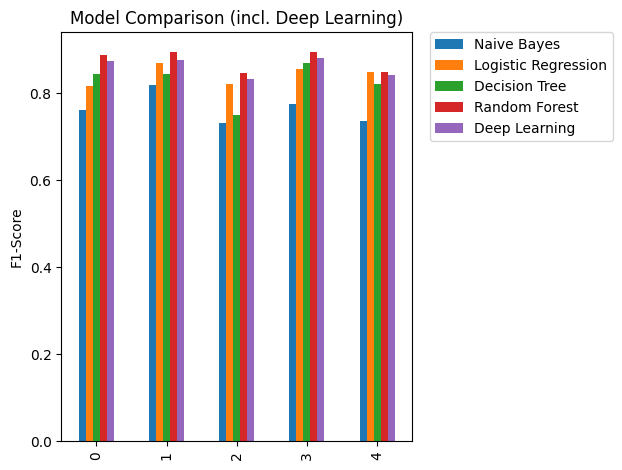

In [12]:
model_results_df = pd.DataFrame(model_results)
model_results_df.plot(kind='bar')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title('Model Comparison (incl. Deep Learning)')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

In [13]:
full_summary = pd.DataFrame({
    'Mean F1-Score': model_results_df.mean(),
    'Std Deviasi (Kestabilan)': model_results_df.std(),
}).sort_values(by=['Mean F1-Score', 'Std Deviasi (Kestabilan)'], ascending=[False, True])
print('=== Peringkat Model ===')
print(full_summary)
print('-' * 30)
best_model_name = full_summary.index[0]
best_model_f1 = full_summary['Mean F1-Score'].iloc[0]
print(f'\nModel terbaik: {best_model_name} (F1 = {best_model_f1:.4f})')

=== Peringkat Model ===
                     Mean F1-Score  Std Deviasi (Kestabilan)
Random Forest             0.874939                  0.024742
Deep Learning             0.861621                  0.022151
Logistic Regression       0.842794                  0.022144
Decision Tree             0.826494                  0.045785
Naive Bayes               0.764975                  0.035758
------------------------------

Model terbaik: Random Forest (F1 = 0.8749)


# Hyperparameter Tuning & Final Model

In [14]:
param_grid = {'n_estimators': [200, 500], 'max_depth': [15, 25, None], 'min_samples_leaf': [1, 5]}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
    param_grid, cv=gkf, scoring='f1', verbose=1)
grid.fit(X, y, groups=groups)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [15, 25, ...], 'min_samples_leaf': [1, 5], 'n_estimators': [200, 500]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [15]:
best_rf = grid.best_estimator_
print(f'Best params: {grid.best_params_}')
print(f'Best CV F1: {grid.best_score_:.4f}')

Best params: {'max_depth': 25, 'min_samples_leaf': 5, 'n_estimators': 500}
Best CV F1: 0.8799


In [16]:
joblib.dump(best_rf, BIN_DIR / 'image_classifier.pkl')
print('Saved: image_classifier.pkl')

Saved: image_classifier.pkl


In [17]:
probs = best_rf.predict_proba(X)[:, 1]
best_th, best_f1 = 0.0, 0.0
for th in np.arange(0.3, 0.85, 0.02):
    f1 = f1_score(y, (probs >= th).astype(int))
    if f1 > best_f1:
        best_f1, best_th = f1, th
print(f'Best threshold: {best_th:.2f} (F1={best_f1:.4f})')

Best threshold: 0.54 (F1=0.9709)


In [18]:
with open(BIN_DIR / 'image_best_threshold.json', 'w') as f:
    json.dump({'threshold': float(best_th), 'f1': float(best_f1)}, f)
print('Saved: image_best_threshold.json')

Saved: image_best_threshold.json


In [1]:
oof_probs = np.zeros(len(y))

for train_idx, val_idx in gkf.split(X, y, groups):
    model = clone(best_rf)
    model.fit(X[train_idx], y[train_idx])

    oof_probs[val_idx] = model.predict_proba(X[val_idx])[:, 1]

y_pred_oof = (oof_probs >= best_th).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_oof,
    display_labels=["non-gambling", "gambling"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

print("\n=== Classification Report ===")
print(
    classification_report(
        y,
        y_pred_oof,
        target_names=["non-gambling", "gambling"],
        digits=4
    )
)

NameError: name 'np' is not defined